# Observational Data

Most data available to an actuary is **observational**: policyholders, patients, or drivers are *not* randomly assigned to a treatment (a wellness programme, a discount, a new pricing rule). Instead, who receives the treatment is driven by self-selection, eligibility rules, or underwriting decisions — the very factors that also influence the outcome. This is what makes naive comparisons misleading.

This notebook walks through the practical workflow for turning observational data into a credible causal statement. Using a synthetic insurance-style dataset, we:

1. **Encode our assumptions** in a causal graph (DAG)
2. **Validate each of the four identification assumptions** — {prf:ref}`consistency`, {prf:ref}`sutva`, {prf:ref}`positivity`, and {prf:ref}`exchangeability` — graphically and statistically, using the diagnostics and sensitivity tools from {doc}`../tutorial/4_sensitivity`.
3. **Show what to do when an assumption fails**, mapping each violation to a concrete remedy (trimming, overlap weighting, sensitivity analysis) following {doc}`../tutorial/2_3_debias`.

The goal is a reusable checklist: before reporting any treatment effect from observational data, an actuary should be able to point to the diagnostic that supports — or qualifies — each assumption.


### Toolkit: Dealing with Violated Assumptions

Recall from {doc}`../tutorial/2_1_assumptions` that an observational study can be treated as a *conditionally randomized experiment* only if four assumptions hold. Each one can be probed — some directly from data, others only indirectly:

| Assumption | What it requires | How we validate it here | If violated → remedy |
|---|---|---|---|
| {prf:ref}`consistency` | The treatment is well-defined (one version) | Re-estimate the effect by treatment sub-type | Split into well-defined treatments; estimate each separately |
| {prf:ref}`sutva` | No interference between units | Correlate control outcomes with neighbours' treatment intensity | Cluster / partial-interference models; randomise at group level |
| {prf:ref}`positivity` | Every covariate profile *can* receive both arms | Propensity-score overlap (box / mirror plots) | **Restrict** (trim to common support) or **reweight** (overlap weights) |
| {prf:ref}`exchangeability` | No unmeasured confounding given $X$ | Balance (SMD / Love plot) + sensitivity analysis | Richer adjustment set, instrumental variables, or report robustness (E-value, RV, critical Γ) |

The first three leave **detectable footprints** in the data. The fourth — exchangeability — is fundamentally untestable, so we instead ask *how robust* our conclusion is to a hypothetical unmeasured confounder (E-values, partial $R^2$, Rosenbaum bounds, placebo tests). When a check fails, we reach for the matching tool from the de-biasing toolkit ({doc}`../tutorial/2_3_debias`): **restrict** (trim to the overlap region), **reweight** (overlap weights), **model the structure** (DAG-guided adjustment), or **report a sensitivity bound**.


### The end-to-end pipeline

```{figure} figs/pipeline_observational.svg
:name: obs-pipeline
:width: 100%

The identification workflow for observational data: encode assumptions in a DAG, validate each of the four assumptions, and — if any is violated — apply the matching remedy and re-estimate with a robustness check before reporting transparently.
```



In [1]:
import os
import warnings

import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
import plotly.graph_objects as go
import plotly.subplots as sp
from scipy.special import expit
from IPython.display import SVG, display
from utils import *
import plotly


np.seterr(all="ignore")
warnings.filterwarnings("ignore", category=RuntimeWarning)

plotly.offline.init_notebook_mode(connected=True)


# Folder for the exported causal-graph SVG figures
FIG_DIR = os.path.join("figs")
os.makedirs(FIG_DIR, exist_ok=True)


## A Synthetic Insurance Example

We simulate $N = 1000$ policyholders enrolled (or not) in a voluntary **wellness programme** ($T$). Ten covariates $X_1, \dots, X_{10}$ describe each policyholder (age, risk indicators, etc.), and the outcome $Y$ is a cost/health score we hope the programme improves. Because the data is *synthetic*, we know the ground truth — the true average treatment effect is `ATE = 5.0` — which lets us check whether each diagnostic behaves as expected.

We deliberately build in the imperfections an actuary meets in practice:

- **Two propensity regimes:** a *good* one where enrolment depends only mildly on covariates (positivity holds), and a *violated* one where certain profiles are almost always or never enrolled (positivity fails).
- **An unobserved confounder** $U$ that drives both enrolment and the outcome but is *not* in the covariate set — the source of potential exchangeability violations.
- A **treatment sub-type** (two delivery modes of the same programme) to probe consistency, and a **group structure** with spillovers to probe SUTVA.


In [2]:
# --- 1. Synthetic Data Generation ---
N = 1000  # Number of observations
ATE = 5.0 # Average Treatment Effect
np.random.seed(42)

# Coefficients for the causal model
beta_x1_t = 0.5
beta_x2_t = 1.0
beta_x1_y = 1.0
beta_x2_y = 2.0
intercept_t = -1.5
intercept_y = 10.0
beta_x1_t_v = 5.0  # High coefficient for violation
beta_x2_t_v = 3.0  # High coefficient for violation
intercept_t_v = 0.0
beta_u = 0.8       # strength of the UNOBSERVED confounder on treatment uptake

# Generate Covariates (X)
X1 = np.random.normal(loc=40, scale=10, size=N)
X2 = np.random.binomial(n=1, p=0.4, size=N)

# Generate 8 more covariates
X3 = np.random.uniform(low=0, high=100, size=N)
X4 = np.random.normal(loc=10, scale=2, size=N)
X5 = np.random.randint(low=0, high=5, size=N) # Categorical-like
X6 = np.random.gamma(shape=2, scale=2, size=N)
X7 = np.random.poisson(lam=3, size=N)
X8 = np.random.exponential(scale=1, size=N)
X9 = np.random.normal(loc=50, scale=5, size=N)
X10 = np.random.binomial(n=1, p=0.7, size=N)

# UNOBSERVED confounder U: drives BOTH enrolment and the outcome, but is NOT
# part of the covariate set the analyst gets to use. It is the hidden reason
# why exchangeability can never be fully verified from data.
U = np.random.normal(loc=0, scale=1, size=N)

# Calculate Propensity Scores

# 1. Good Positivity (Mild dependence on X) + hidden dependence on U
# Add new covariates to the linear predictor for 'good' treatment assignment
linear_predictor_t = (
    intercept_t
    + (beta_x1_t * (X1 - X1.mean()) / X1.std())
    + (beta_x2_t * X2)
    + (0.1 * (X3 - X3.mean()) / X3.std()) # Small effect
    + (0.2 * (X4 - X4.mean()) / X4.std()) # Small effect
    + (beta_u * U)                         # hidden confounding via U
)
prob_t = expit(linear_predictor_t)
T = np.random.binomial(n=1, p=prob_t, size=N)

# 2. Bad Positivity (Extreme dependence on X)
# Add new covariates to the linear predictor for 'violate' treatment assignment (with higher coefficients)
linear_predictor_t_v = (
    intercept_t_v
    + (beta_x1_t_v * (X1 - X1.mean()) / X1.std())
    + (beta_x2_t_v * X2)
    + (1.5 * (X3 - X3.mean()) / X3.std()) # Larger effect
    + (1.0 * (X4 - X4.mean()) / X4.std()) # Larger effect
    + (0.8 * X5) # Larger effect for categorical
)
prob_t_violate = expit(linear_predictor_t_v)
T_Violate = np.random.binomial(n=1, p=prob_t_violate, size=N)

# Create DataFrame including all covariates
data = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'X4': X4,
    'X5': X5,
    'X6': X6,
    'X7': X7,
    'X8': X8,
    'X9': X9,
    'X10': X10,
    'U_unobserved': U,
    'T_Treatment': T,
    'T_Violate_Positivity': T_Violate,
    'P_Propensity_Score_Good': prob_t,
    'P_Propensity_Score_Violate': prob_t_violate
})

data.head(5)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,U_unobserved,T_Treatment,T_Violate_Positivity,P_Propensity_Score_Good,P_Propensity_Score_Violate
0,44.967142,0,21.906881,8.786599,4,2.594468,2,0.123125,52.142193,0,-0.085092,0,1,0.176659,0.973667
1,38.617357,0,3.672136,10.422567,3,2.009630,4,0.864453,47.578047,1,-0.814118,0,0,0.087018,0.357944
2,46.476885,1,10.802575,12.400158,1,3.812620,0,0.453005,47.091020,0,-0.749608,1,1,0.336216,0.997901
3,55.230299,1,33.886065,9.016195,4,0.319852,4,0.083726,49.157490,1,0.232870,1,1,0.575266,0.999997
4,37.658466,0,80.258568,6.246895,1,1.507062,1,2.180253,44.745755,1,-1.635828,0,0,0.039227,0.325387


In [3]:
# --- 2. Outcomes used to validate the four assumptions ---
X1_std = (X1 - X1.mean()) / X1.std()

# Structural outcome model:  Y = baseline + ATE*T + observed confounders + U + noise.
# Because U is omitted from any analysis, it induces *unmeasured* confounding.
noise_y = np.random.normal(loc=0, scale=2.0, size=N)
Y = (
    intercept_y
    + ATE * T
    + beta_x1_y * X1_std
    + beta_x2_y * X2
    + 1.5 * U
    + noise_y
)

# Treatment SUB-TYPE -> probes CONSISTENCY.
# The single label "T = 1" actually hides two delivery modes (0 and 1) of the
# programme; mode 1 is slightly more effective, so the treatment is not a single
# well-defined intervention.
Treatment_Subtype = np.where(T == 1, np.random.binomial(1, 0.5, N), -1)  # -1 = untreated
Y = Y + np.where(Treatment_Subtype == 1, 1.5, 0.0)

# GROUP structure with spillovers -> probes SUTVA (no interference).
# Untreated policyholders benefit when more of their group is treated.
n_groups = 200
Group_ID = np.random.randint(0, n_groups, size=N)
group_treat_rate = pd.Series(T).groupby(Group_ID).transform('mean').values
Y_Spillover = Y + 3.0 * group_treat_rate * (1 - T)

# NEGATIVE-CONTROL outcome -> used for the placebo / falsification test.
# Driven by the confounders and U, but by construction NOT by the treatment T.
Y_Negative_Control = (
    5.0
    + beta_x1_y * X1_std
    + beta_x2_y * X2
    + 1.5 * U
    + np.random.normal(loc=0, scale=2.0, size=N)
)

# Outcome generated under the VIOLATED-positivity assignment T_Violate, with the
# SAME causal effect (ATE) and observed confounding. Used in the positivity
# remedy section so the comparison against the known ATE is meaningful.
Y_Violate = (
    intercept_y
    + ATE * T_Violate
    + beta_x1_y * X1_std
    + beta_x2_y * X2
    + np.random.normal(loc=0, scale=2.0, size=N)
)

data['Y'] = Y
data['Treatment_Subtype'] = Treatment_Subtype
data['Group_ID'] = Group_ID
data['Y_Spillover'] = Y_Spillover
data['Y_Negative_Control'] = Y_Negative_Control
data['Y_Violate'] = Y_Violate

data[['T_Treatment', 'Treatment_Subtype', 'Group_ID', 'Y', 'Y_Negative_Control']].head()


,T_Treatment,Treatment_Subtype,Group_ID,Y,Y_Negative_Control
0,0,-1,137,12.163872,4.647940
1,0,-1,180,9.132436,7.689888
2,1,1,178,15.482761,5.683803
3,1,1,196,18.293101,6.803677
4,0,-1,13,6.944880,3.454130


In [4]:
# DAG Plot
causal_model = {
    'X1 -> T': beta_x1_t,
    'X2 -> T': beta_x2_t,
    'X1 -> Y': beta_x1_y,
    'X2 -> Y': beta_x2_y,
    'T -> Y': ATE
}

print("Causal Model (DAG Structure and Weights):")
for path, weight in causal_model.items():
    print(f"{path}: {weight}")

causal_model_violate_positivity = {
    'X1 -> T': beta_x1_t_v,
    'X2 -> T': beta_x2_t_v,
    'X1 -> Y': beta_x1_y,
    'X2 -> Y': beta_x2_y,
    'T -> Y': ATE
}

print("Causal Model with violated positivity(DAG Structure and Weights):")
for path, weight in causal_model_violate_positivity.items():
    print(f"{path}: {weight}")

Causal Model (DAG Structure and Weights):
X1 -> T: 0.5
X2 -> T: 1.0
X1 -> Y: 1.0
X2 -> Y: 2.0
T -> Y: 5.0
Causal Model with violated positivity(DAG Structure and Weights):
X1 -> T: 5.0
X2 -> T: 3.0
X1 -> Y: 1.0
X2 -> Y: 2.0
T -> Y: 5.0


## Encoding Assumptions in a Causal Graph

Before touching the data we make our assumptions explicit with a **directed acyclic graph** (DAG). The DAG is the contract: it states which variables confound the treatment–outcome relationship and therefore which must be adjusted for ({prf:ref}`backdoor-criterion`).

We export each graph as a stand-alone **`*.svg`** file (vector graphics stay crisp at any zoom in the rendered book) and embed it below.

- **Left — the analyst's model:** observed confounders $X_1, X_2$ open backdoor paths $X \rightarrow T$ and $X \rightarrow Y$. Adjusting for them closes the paths, so the effect of $T$ on $Y$ is identified.
- **Right — the uncomfortable reality:** an *unobserved* confounder $U$ (dashed) also drives both $T$ and $Y$. Its backdoor path $T \leftarrow U \rightarrow Y$ (red, dashed) **cannot** be closed by adjustment, which is exactly what threatens {prf:ref}`exchangeability`.


Saved SVG figures:
 - figs/dag_observational.svg
 - figs/dag_unobserved.svg


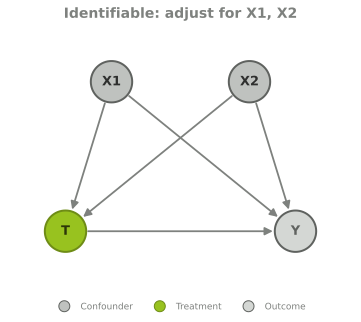

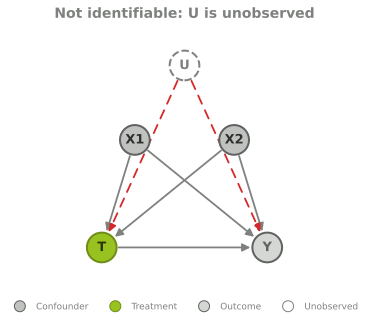

In [5]:
# Build two causal graphs and export them as embeddable SVG files.

# Layout shared by both graphs
base_pos = {
    'X1': (-0.6, 1.0),
    'X2': (0.6, 1.0),
    'T': (-1.0, -0.3),
    'Y': (1.0, -0.3),
}
base_styles = {'X1': 'confounder', 'X2': 'confounder', 'T': 'treatment', 'Y': 'outcome'}

# (a) The analyst's model: only observed confounders. All backdoor paths closable.
svg_observed = draw_causal_graph_svg(
    edges=[('X1', 'T'), ('X1', 'Y'), ('X2', 'T'), ('X2', 'Y'), ('T', 'Y')],
    positions=base_pos,
    node_styles=base_styles,
    filepath=os.path.join(FIG_DIR, 'dag_observational.svg'),
    title='Identifiable: adjust for X1, X2',
    legend_types=['confounder', 'treatment', 'outcome'],
)

# (b) Reality: an unobserved confounder U opens a backdoor path that adjustment
#     cannot close (its edges are drawn as dashed-red 'biasing' arrows).
pos_u = dict(base_pos, U=(0.0, 1.9))
styles_u = dict(base_styles, U='unobserved')
svg_unobserved = draw_causal_graph_svg(
    edges=[('X1', 'T'), ('X1', 'Y'), ('X2', 'T'), ('X2', 'Y'), ('T', 'Y'),
           ('U', 'T', 'biasing'), ('U', 'Y', 'biasing')],
    positions=pos_u,
    node_styles=styles_u,
    filepath=os.path.join(FIG_DIR, 'dag_unobserved.svg'),
    title='Not identifiable: U is unobserved',
    legend_types=['confounder', 'treatment', 'outcome', 'unobserved'],
)

print('Saved SVG figures:')
print(' -', svg_observed)
print(' -', svg_unobserved)

# Embed the vector graphics side by side
display(SVG(svg_observed))
display(SVG(svg_unobserved))


## Assumption 1 — Consistency

{prf:ref}`consistency` requires the treatment to be **well-defined**: a single, unambiguous intervention. If "enrolled in the programme" secretly bundles several different delivery modes, then $Y(1)$ is not a single quantity and the estimated effect is an uninterpretable average.

**Diagnostic.** We re-estimate the (regression-adjusted) effect *separately for each treatment sub-type*, comparing each against the common control group. A stable effect across sub-types is reassuring; substantial variation flags an ambiguous treatment that should be split into distinct interventions.


In [6]:
# Re-estimate the effect within each treatment sub-type (delivery mode).
covariates_adj = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']
consistency_tbl = consistency_diagnostic(
    data, treatment='T_Treatment', outcome='Y',
    subtype_col='Treatment_Subtype', covariates=covariates_adj,
)
display(consistency_tbl.round(3))

# Visualise the effect per sub-type with ±1.96 SE error bars
fig = go.Figure()
fig.add_trace(go.Bar(
    x=consistency_tbl['Group'], y=consistency_tbl['Effect'],
    error_y=dict(type='data', array=1.96 * consistency_tbl['Std. Error']),
    marker_color=['#555555', '#1f77b4', '#ff7f0e'][:len(consistency_tbl)],
))
fig.add_hline(y=ATE, line_dash='dash', line_color='green',
              annotation_text=f'True ATE = {ATE}', annotation_position='top left')
fig.update_layout(title_text='Estimated effect by treatment sub-type',
                  yaxis_title='Effect on Y', xaxis_title='')
show(fig)


,Group,Effect,Std. Error,n_treated
0,Overall (pooled),6.801,0.184,267
1,Sub-type 0,6.129,0.235,137
2,Sub-type 1,7.483,0.241,130


```{note} Interpretation — consistency
:class: dropdown

The two delivery modes give **different** effects, so the single label *"treated"* is **not** a well-defined treatment — {prf:ref}`consistency` is questionable.

**Remedy:** define each delivery mode as its own treatment and estimate the effects separately.
```


## Assumption 2 — SUTVA (No Interference)

{prf:ref}`sutva` requires that one unit's treatment does **not** affect another unit's outcome. In insurance this fails through *spillovers*: a group discount changes behaviour across a whole household or employer group, so untreated members are indirectly affected.

**Diagnostic.** For every policyholder we compute the **leave-one-out treatment intensity** of their group (the share of *other* members who are treated). Under no interference, the outcomes of *control* units should be uncorrelated with this intensity. A significant correlation is direct evidence of spillover.


In [7]:
# Run the interference diagnostic on two outcomes:
#  - Y           : generated WITHOUT spillover (SUTVA holds)
#  - Y_Spillover : untreated units benefit from treated neighbours (SUTVA violated)
r_clean, p_clean, _ = interference_diagnostic(data, 'Group_ID', 'T_Treatment', 'Y')
r_spill, p_spill, ctrl_spill = interference_diagnostic(data, 'Group_ID', 'T_Treatment', 'Y_Spillover')

print(f"No-spillover outcome  Y           : r = {r_clean:+.3f}  (p = {p_clean:.3f})")
print(f"Spillover outcome     Y_Spillover : r = {r_spill:+.3f}  (p = {p_spill:.3f})")

fig = sp.make_subplots(rows=1, cols=2, subplot_titles=(
    'SUTVA holds (Y)', 'SUTVA violated (Y_Spillover)'))
for col, (outcome, ctrl) in enumerate(
        [('Y', interference_diagnostic(data, 'Group_ID', 'T_Treatment', 'Y')[2]),
         ('Y_Spillover', ctrl_spill)], start=1):
    fig.add_trace(go.Scatter(
        x=ctrl['cluster_treat_intensity'], y=ctrl[outcome], mode='markers',
        marker=dict(color='forestgreen', size=5, opacity=0.5), showlegend=False,
    ), row=1, col=col)
    # OLS trend line
    m, b = np.polyfit(ctrl['cluster_treat_intensity'], ctrl[outcome], 1)
    xs = np.linspace(0, 1, 50)
    fig.add_trace(go.Scatter(x=xs, y=m * xs + b, mode='lines',
                             line=dict(color='red', width=2), showlegend=False),
                  row=1, col=col)
fig.update_xaxes(title_text="Neighbours' treatment intensity")
fig.update_yaxes(title_text='Control-unit outcome', col=1)
fig.update_layout(height=400,
                  title_text='Interference check: control outcomes vs. neighbours’ treatment')
show(fig)


No-spillover outcome  Y           : r = -0.035  (p = 0.343)
Spillover outcome     Y_Spillover : r = +0.136  (p = 0.000)


```{note} Interpretation — SUTVA
:class: dropdown

A flat cloud (left) is consistent with **no interference**; the upward slope (right) reveals **spillover**, so {prf:ref}`sutva` is violated.

**Remedy:** assign and analyse treatment at the **group level** (partial-interference or cluster models).
```


## Assumption 3 — Positivity

{prf:ref}`positivity` requires that *every* covariate profile has a non-trivial chance of receiving **both** treatment and control: $0 < \pi(x) < 1$. It is the most **directly diagnosable** assumption — we simply inspect the estimated propensity scores $\hat{\pi}(x)$ by treatment group and look for **non-overlap** (mass piling up near 0 or 1).

The box / mirror plots below contrast our two regimes. Under *good* positivity the treated and control score distributions overlap broadly. Under the *violated* regime they separate: some profiles are almost always (or never) enrolled, leaving regions with no comparable units. There, inverse-probability weights $1/\hat{\pi}(x)$ explode and estimates become unstable ({doc}`../tutorial/2_3_debias`).


In [8]:
# --- Plotly Boxplot Execution and Display ---
# Create boxplot for Good Overlap
fig_boxplot_good = plot_propensity_score_boxplots(
    data,
    'P_Propensity_Score_Good',
    'T_Treatment',
    'Boxplots of Propensity Scores: Good Positivity'
)
show(fig_boxplot_good)

# Create boxplot for Severe Violation
fig_boxplot_violate = plot_propensity_score_boxplots(
    data,
    'P_Propensity_Score_Violate',
    'T_Violate_Positivity',
    'Boxplots of Propensity Scores: Violation of Positivity'
)
show(fig_boxplot_violate)


### Remedy when positivity fails: restrict and reweight

When overlap is poor, two complementary fixes from the de-biasing toolkit apply:

- **Restrict (trimming):** drop units with $\hat{\pi}(x) < \varepsilon$ or $\hat{\pi}(x) > 1 - \varepsilon$ and target the *trimmed* population where both arms are plausible.
- **Reweight (overlap weights):** weight each unit by $\pi(x)(1-\pi(x))$, which smoothly down-weights non-overlap units and targets the *overlap population* — the group for whom the treatment decision is genuinely uncertain.

Below we estimate the effect under the *violated* regime three ways and compare against the known truth (`ATE = 5.0`). Naive IPW is destabilised by extreme weights; trimming and overlap weighting recover a far more reliable estimate.


In [9]:
# Work in the VIOLATED-positivity regime and estimate the effect on Y.
ps_cols = ['X1', 'X2', 'X3', 'X4', 'X5']
ps_violate = estimate_propensity(data, 'T_Violate_Positivity', ps_cols)

# (a) Naive stabilised IPW on the full sample -> extreme weights
ate_full, w_full = ipw_ate(data, 'T_Violate_Positivity', 'Y', ps_violate)

# (b) Restrict: trim to the common-support region [eps, 1-eps]
trimmed, ps_trim, keep = trim_common_support(data, ps_violate, eps=0.05)
ate_trim, w_trim = ipw_ate(trimmed, 'T_Violate_Positivity', 'Y', ps_trim)

# (c) Reweight: overlap weights on the full sample
ate_overlap, w_overlap = overlap_weighted_ate(data, 'T_Violate_Positivity', 'Y', ps_violate)

summary = pd.DataFrame({
    'Method': ['Naive IPW (full)', 'IPW after trimming', 'Overlap weighting'],
    'ATE estimate': [ate_full, ate_trim, ate_overlap],
    'Max weight': [w_full.max(), w_trim.max(), w_overlap.max()],
    'Units used': [len(data), int(keep.sum()), len(data)],
})
print(f"True ATE = {ATE}\n")
display(summary.round(3))

print(f"\nTrimming removed {int((~keep).sum())} units in the non-overlap region. "
      "Note how the maximum weight collapses and the estimate moves back toward the truth.")


True ATE = 5.0



,Method,ATE estimate,Max weight,Units used
0,Naive IPW (full),-0.293,22.099,1000
1,IPW after trimming,0.926,10.243,355
2,Overlap weighting,0.092,0.985,1000



Trimming removed 645 units in the non-overlap region. Note how the maximum weight collapses and the estimate moves back toward the truth.


## Assumption 4 — Exchangeability

{prf:ref}`exchangeability` — no unmeasured confounding given $X$ — is the **strongest and least verifiable** assumption. We cannot test it directly, but we can do two things:

1. **Check balance on the *observed* confounders.** If adjustment (weighting/matching) has worked, the treated and control groups should look alike on every measured covariate. The **standardised mean difference (SMD)** ({prf:ref}`smd`) summarises each covariate's imbalance; the rule of thumb is $|\text{SMD}| < 0.1$. A **Love plot** displays them all at once.
2. **Stress-test against the *unobserved*.** Because balance on $X$ says nothing about the hidden confounder $U$, we follow up with **sensitivity analysis** (next section).

The Love plot below contrasts the good-positivity and violated regimes. Good balance is necessary but **not sufficient** for exchangeability — it only rules out imbalance in what we measured.


In [10]:
# Define covariates to check balance for
covariates_to_balance = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']

# Create a subplot figure for both plots
fig = sp.make_subplots(rows=1, cols=2, subplot_titles=(
    '1. Good Positivity',
    '2. Severe Violation of Positivity'
))

# Calculate SMD for Good Overlap case
smd_good = calculate_smd(data, covariates_to_balance, 'T_Treatment')

# Calculate SMD for Severe Violation case
smd_violate = calculate_smd(data, covariates_to_balance, 'T_Violate_Positivity')

# Determine a common x-axis limit for both plots
max_smd_abs = max(smd_good.abs().max(), smd_violate.abs().max())
common_x_limit = max_smd_abs + 0.1 # Add a small buffer

# Plot SMD for Good Overlap case (subplot 1)
plot_love_plot(smd_good, '1. Good Overlap', fig, row=1, col=1, x_limit=common_x_limit, dot_color='skyblue')

# Plot SMD for Severe Violation case (subplot 2)
plot_love_plot(smd_violate, '2. Severe Violation', fig, row=1, col=2, x_limit=common_x_limit, dot_color='skyblue')

# Update overall layout of the figure
fig.update_layout(height=500, showlegend=False)
show(fig)


## Sensitivity Analysis for Unmeasured Confounding

Balanced covariates do not prove exchangeability — our data still contains the hidden confounder $U$. Since we cannot adjust for what we do not observe, we instead quantify **how robust** the estimated effect is to a plausible unmeasured confounder, using the four tools from {doc}`../tutorial/4_sensitivity`:

- **E-value** — the minimum strength (on a risk-ratio scale) an unmeasured confounder would need with *both* $T$ and $Y$ to explain the effect away.
- **Partial $R^2$ / robustness value** (Cinelli & Hazlett) — benchmarked against observed covariates.
- **Rosenbaum bounds** — the critical odds-of-assignment ratio $\Gamma$ at which significance is lost.
- **Placebo / negative-control test** — the treatment should show *no* effect on an outcome it cannot affect.

We start from the regression-adjusted estimate (adjusting for the observed $X_1,\dots,X_{10}$ but **not** $U$).


In [11]:
# Regression-adjusted effect of the programme (adjusting for observed X only)
effect = ols_treatment_effect(data, outcome='Y', treatment='T_Treatment',
                              covariates=covariates_adj)
print(f"Adjusted effect estimate : {effect['coef']:.3f}  (SE {effect['se']:.3f}, "
      f"t = {effect['t']:.2f}, p = {effect['p']:.1e})")
print(f"True ATE                 : {ATE}   <- bias remains because U is unobserved\n")

# --- E-value (VanderWeele & Ding) ---
ev = e_value_from_effect(effect['coef'], effect['se'], sd_outcome=data['Y'].std())
print(f"E-value (point estimate) : {ev['e_value']:.2f}")
print(f"E-value (CI limit)       : {ev['e_value_ci']:.2f}")

# --- Robustness value (Cinelli & Hazlett) ---
rv = robustness_value(effect['t'], effect['dof'])
print(f"Robustness value (RV)    : {rv:.3f}")
print(f"\nReading: an unmeasured confounder would need a partial R-squared of at least "
      f"{rv:.1%} with BOTH treatment and outcome to drive the effect to zero, or an "
      f"association of at least RR = {ev['e_value']:.2f} with each. Larger values = more robust.")


Adjusted effect estimate : 6.801  (SE 0.184, t = 37.02, p = 0.0e+00)
True ATE                 : 5.0   <- bias remains because U is unobserved

E-value (point estimate) : 7.90
E-value (CI limit)       : 7.27
Robustness value (RV)    : 0.673

Reading: an unmeasured confounder would need a partial R-squared of at least 67.3% with BOTH treatment and outcome to drive the effect to zero, or an association of at least RR = 7.90 with each. Larger values = more robust.


### Partial $R^2$ contours, benchmarked against observed covariates

The contour plot below ({prf:ref}`partial-r2`) shows the bias-adjusted estimate across a grid of confounder strengths $(R^2_{T \sim U}, R^2_{Y \sim U})$. The thick black line marks where the effect would be driven to **zero**. The dark grey diamond benchmarks "an unmeasured confounder *as strong as the observed covariate* $X_2$" — if that point sits far from the zero line, even a confounder of that strength would not overturn the conclusion.


In [12]:
# Benchmark: how strongly is the observed covariate X2 associated with T and Y?
def _partial_r2(df, target, focal, others):
    res = ols_treatment_effect(df, outcome=target, treatment=focal, covariates=others)
    return res['t'] ** 2 / (res['t'] ** 2 + res['dof'])

others_x2 = [c for c in covariates_adj if c != 'X2']
r2_x2_y = _partial_r2(data, 'Y', 'X2', ['T_Treatment'] + others_x2)
r2_x2_t = _partial_r2(data, 'T_Treatment', 'X2', others_x2)
print(f"Observed covariate X2 — partial R² with Y: {r2_x2_y:.3f}, with T: {r2_x2_t:.3f}")

benchmark = {'r2_tu': r2_x2_t, 'r2_yu': r2_x2_y, 'label': 'as strong as X2'}
fig = plot_sensitivity_contour(effect['coef'], effect['se'], effect['dof'],
                               title='Partial R² sensitivity contours',
                               benchmark=benchmark)
show(fig)


Observed covariate X2 — partial R² with Y: 0.099, with T: 0.044


### Rosenbaum bounds (matched design)

For a matched analysis, {prf:ref}`rosenbaum-gamma` asks: how much could the odds of treatment differ between two units with identical observed covariates — because of a hidden confounder — before our conclusion breaks? We form 1:1 propensity-score-matched pairs, then trace the **worst-case p-value** as $\Gamma$ grows. The **critical $\Gamma$** (where the curve crosses $\alpha = 0.05$) is the headline robustness number: the larger it is, the more hidden bias the finding can absorb.


In [13]:
# 1:1 nearest-neighbour matching on the estimated propensity score
ps_good = estimate_propensity(data, 'T_Treatment', covariates_adj)
treated_mask = data['T_Treatment'].values == 1
y_all = data['Y'].values

ctrl_ps = ps_good[~treated_mask]
ctrl_y = y_all[~treated_mask]
treat_ps = ps_good[treated_mask]
treat_y = y_all[treated_mask]

# Matched-pair outcome differences (treated - nearest control)
pair_diffs = [ty - ctrl_y[np.argmin(np.abs(ctrl_ps - tp))]
              for tp, ty in zip(treat_ps, treat_y)]

gammas = np.round(np.arange(1.0, 3.01, 0.25), 2)
bounds = rosenbaum_sensitivity(pair_diffs, gammas)
below = bounds.loc[bounds['p_upper_bound'] < 0.05, 'Gamma']
critical_gamma = below.max() if len(below) else None
print(f"Critical Γ (significance retained up to): {critical_gamma}")
display(bounds.round(4))

show(plot_rosenbaum(bounds, alpha=0.05))


Critical Γ (significance retained up to): 3.0


,Gamma,p_upper_bound
0,1.00,0.0
1,1.25,0.0
2,1.50,0.0
3,1.75,0.0
4,2.00,0.0
5,2.25,0.0
6,2.50,0.0
7,2.75,0.0
8,3.00,0.0


### Placebo / negative-control test

A final falsification check ({prf:ref}`placebo-test`): apply the *same* estimator to a **negative-control outcome** — one the programme cannot plausibly affect, but which shares the confounding structure. If exchangeability (given $X$) held, the estimated "effect" on this outcome should be **zero**. A non-zero estimate is a red flag for residual confounding.

Here the negative control is driven by $X_1, X_2$ and the hidden $U$ but **not** by $T$. Because $U$ is omitted from the adjustment set, the test should detect the leakage — demonstrating exactly how a placebo test surfaces unmeasured confounding.


In [14]:
# Real outcome vs. negative-control outcome, same estimator and adjustment set
real = ols_treatment_effect(data, 'Y', 'T_Treatment', covariates_adj)
placebo = negative_control_test(data, 'Y_Negative_Control', 'T_Treatment', covariates_adj)

placebo_tbl = pd.DataFrame({
    'Outcome': ['Y (real)', 'Y_Negative_Control (placebo)'],
    'Estimated effect': [real['coef'], placebo['coef']],
    'Std. Error': [real['se'], placebo['se']],
    'p-value': [real['p'], placebo['p']],
    'Expected': ['≈ true ATE', '≈ 0 if exchangeable'],
})
display(placebo_tbl.round(3))

if placebo['p'] < 0.05:
    print(f"\nThe placebo effect is significantly non-zero (p = {placebo['p']:.1e}) -> "
          "residual (unmeasured) confounding is present, consistent with the hidden U. "
          "Remedy: seek a richer adjustment set, an instrument, or report the sensitivity "
          "bounds above alongside the estimate.")
else:
    print(f"\nThe placebo effect is not distinguishable from zero (p = {placebo['p']:.2f}) -> "
          "no evidence of residual confounding from this test.")


,Outcome,Estimated effect,Std. Error,p-value,Expected
0,Y (real),6.801,0.184,0.0,≈ true ATE
1,Y_Negative_Control (placebo),1.028,0.180,0.0,≈ 0 if exchangeable



The placebo effect is significantly non-zero (p = 1.4e-08) -> residual (unmeasured) confounding is present, consistent with the hidden U. Remedy: seek a richer adjustment set, an instrument, or report the sensitivity bounds above alongside the estimate.


```{note} Summary — what this notebook demonstrated
:class: dropdown

- ✅ **Causal graph** encoded (identifiable vs. unobserved-confounder case).
- ✅ **Consistency** probed by re-estimating the effect per treatment sub-type.
- ✅ **SUTVA** probed by correlating control outcomes with neighbours' treatment intensity.
- ✅ **Positivity** assessed via propensity overlap, then *restored* by trimming and overlap weighting.
- ✅ **Exchangeability** checked for observed balance (SMD / Love plot) and stress-tested with **E-values, partial $R^2$ contours, Rosenbaum bounds, and a placebo test**.
```

## Reality Check: LaLonde (1986) revisited

How well do these diagnostics actually substitute for a randomized experiment? The canonical stress-test is [LaLonde (1986)](https://www.jstor.org/stable/1806062), who took a job-training RCT (the *National Supported Work* programme), threw away the experimental control group, and tried to recover the known experimental benchmark from *nonexperimental* comparison groups. His verdict was sobering: the econometric methods of the day **could not systematically replicate the experimental estimate** — a result that cast a long shadow over observational causal inference.

[Imbens & Xu (2024)](https://doi.org/10.48550/arXiv.2406.00827) revisit that same data four decades later, asking what the methods developed since have actually bought us. Their reassessment maps almost one-to-one onto the four {doc}`identification assumptions <../tutorial/2_1_assumptions>` and the {doc}`diagnostics and sensitivity checks <../tutorial/4_1_diagnostics>` used in this notebook:

- **Separate unconfoundedness from functional form.** Much of LaLonde's original failure came from extrapolating linear models into regions with no comparable units — *not* from {prf:ref}`exchangeability` per se. Stating the adjustment set on a DAG, independent of the regression specification, is the modern discipline (our step 1).
- **Overlap is decisive.** When the treated and comparison groups genuinely overlap in covariate space, modern estimators (propensity-score and **doubly robust** methods) recover *stable, robust* adjusted differences. Where overlap is poor, no estimator rescues the comparison — exactly the failure that {prf:ref}`positivity` and its {prf:ref}`balance diagnostics <smd>` (box/mirror and Love plots) are designed to catch, with trimming/overlap-weighting as the remedy.
- **Robust ≠ causal.** Their sharpest warning: an estimate can be numerically stable and pass goodness-of-fit checks while still being **biased by unmeasured confounding**. Goodness-of-fit tells you nothing about {prf:ref}`exchangeability`; only a {prf:ref}`sensitivity analysis <e-value>` ({prf:ref}`E-values <e-value>`, {prf:ref}`partial $R^2$ <partial-r2>`, {prf:ref}`Rosenbaum bounds <rosenbaum-gamma>`) quantifies how much hidden bias the conclusion could absorb.
- **Validation exercises are essential.** What *does* probe credibility is out-of-sample validation against an experimental or {prf:ref}`placebo / negative-control <placebo-test>` benchmark — precisely the falsification test we ran above, and the reason our placebo correctly flags the hidden confounder $U$.

The throughline is reassuring for the careful analyst: the four-assumption discipline of this notebook — *inspect the assignment process, scrutinise overlap, and validate rather than assume* — is exactly the toolkit that turns LaLonde's pessimism into the qualified, defensible estimates Imbens & Xu obtain.

## Takeaways for the actuary

```{admonition} A practical workflow for observational data
:class: tip

1. **Draw the DAG first.** State the treatment, the outcome, and the adjustment set *before* looking at estimates — this fixes which variables are confounders, mediators, or colliders, and keeps {prf:ref}`exchangeability` separate from the functional form of any model.
2. **Diagnose, don't assume.** {prf:ref}`consistency`, {prf:ref}`sutva` and {prf:ref}`positivity` leave footprints in the data; run the corresponding check rather than taking them on faith.
3. **Make overlap the gatekeeper.** LaLonde's reanalysis shows estimates are only trustworthy where the treated and control groups genuinely overlap. Inspect $\hat{\pi}(x)$ and the {prf:ref}`balance diagnostics <smd>`, then **trim or reweight** to the common-support population before reporting anything.
4. **Robust is not the same as causal.** A stable estimate that passes goodness-of-fit can still be confounded. Treat {prf:ref}`exchangeability` as a matter of degree: always pair the point estimate with a **sensitivity analysis** ({prf:ref}`E-value <e-value>`, {prf:ref}`robustness value / partial $R^2$ <partial-r2>`, {prf:ref}`critical $\Gamma$ <rosenbaum-gamma>`) and a {prf:ref}`validation / placebo test <placebo-test>` against a benchmark the treatment cannot affect.
5. **Match the remedy to the violation.** Redefine an ambiguous treatment; model spillovers at the group level; trim or reweight to fix positivity; enrich the adjustment set or use an instrument for hidden confounding. Where no assumption pins the effect down, report worst-case {prf:ref}`Manski bounds <manski-bounds>`.
6. **Report transparently.** A decision-maker is far better served by *"effect = X, robust to a confounder up to strength Y"* than by a single unqualified number.
```

**The bottom line.** Observational data can support credible causal statements, but **only when each identification assumption is explicitly checked and, where needed, repaired**. The four-decade reassessment of [LaLonde (1986)](https://www.jstor.org/stable/1806062) by [Imbens & Xu (2024)](https://doi.org/10.48550/arXiv.2406.00827) sharpens the practical discipline for the actuary moving from prediction to causal inference: in an actuarial causal-inference setting, **the assumption checks _are_ the analysis** — and the estimate is only as trustworthy as the overlap, diagnostics, and validation bounds reported alongside it.